# Airline Fuel EDA

This notebook analyzes the cleaned airline fuel dataset to understand how flight distance, payload, headwind, altitude, and aircraft type relate to fuel consumption.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean/flight_fuel_logs_clean.csv')
df.head()

,distance_km,payload_tonnes,headwind_kts,cruise_altitude_ft,aircraft_type,fuel_kg,fuel_per_km
0,380,9.6,19,37500,B737,2423,6.376316
1,540,8.7,28,36500,B737,3050,5.648148
2,550,8.5,1,32500,B737,3111,5.656364
3,560,12.4,17,32000,B737,3200,5.714286
4,570,12.4,18,32000,B737,3173,5.566667


In [2]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.describe().round(2)

Shape: (120, 7)
Columns: ['distance_km', 'payload_tonnes', 'headwind_kts', 'cruise_altitude_ft', 'aircraft_type', 'fuel_kg', 'fuel_per_km']

Missing values:
 distance_km           0
payload_tonnes        0
headwind_kts          0
cruise_altitude_ft    0
aircraft_type         0
fuel_kg               0
fuel_per_km           0
dtype: int64

Data types:
 distance_km             int64
payload_tonnes        float64
headwind_kts            int64
cruise_altitude_ft      int64
aircraft_type             str
fuel_kg                 int64
fuel_per_km           float64
dtype: object


,distance_km,payload_tonnes,headwind_kts,cruise_altitude_ft,fuel_kg,fuel_per_km
count,120.00,120.00,120.00,120.00,120.00,120.00
mean,2236.83,11.57,4.52,34695.83,8181.07,3.94
std,1081.16,3.44,21.92,2341.89,3258.78,0.68
min,380.00,6.00,-30.00,31000.00,2423.00,3.32
25%,1322.50,8.45,-15.25,32500.00,5437.75,3.45
50%,2190.00,11.45,4.50,34500.00,8011.50,3.71
75%,3265.00,14.42,23.00,36625.00,11357.50,4.14
max,3910.00,17.90,40.00,39000.00,13174.00,6.38


C:\Users\Vijay\AppData\Local\Temp\ipykernel_27156\1534138178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='aircraft_type', palette='Set2')


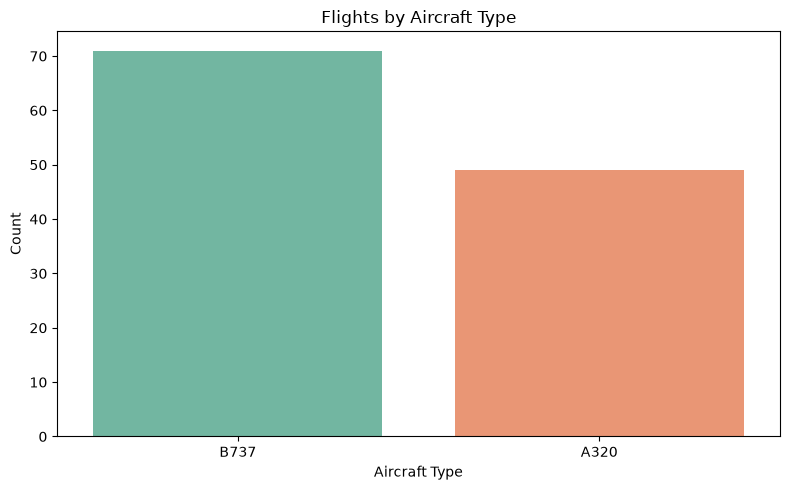

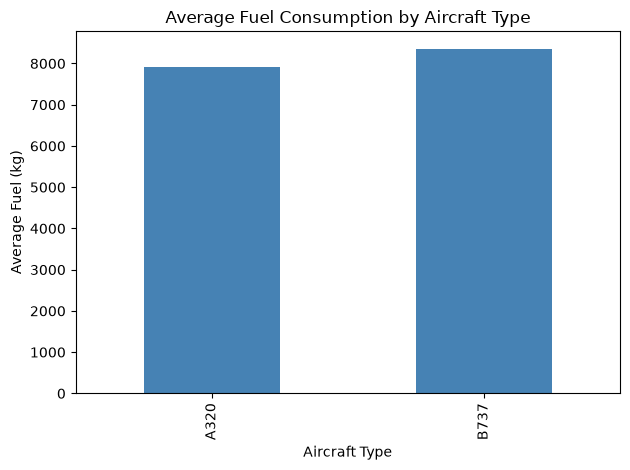

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='aircraft_type', palette='Set2')
plt.title('Flights by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df.groupby('aircraft_type')['fuel_kg'].mean().sort_values().plot(kind='bar', color='steelblue')
plt.title('Average Fuel Consumption by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Average Fuel (kg)')
plt.tight_layout()
plt.show()

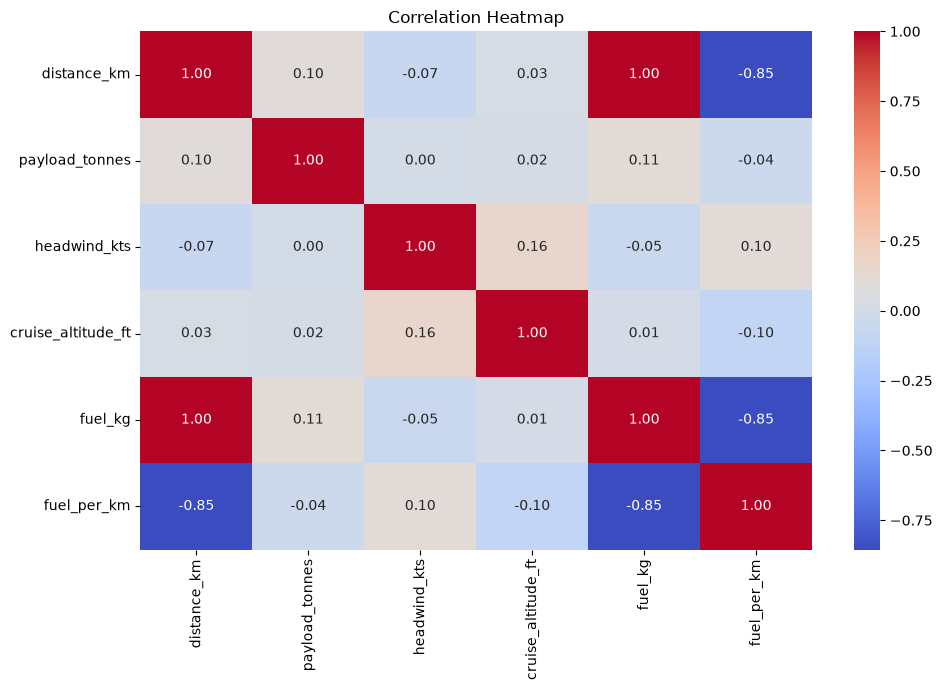

fuel_kg               1.000000
distance_km           0.999020
payload_tonnes        0.109937
cruise_altitude_ft    0.010367
headwind_kts         -0.053627
fuel_per_km          -0.849612
Name: fuel_kg, dtype: float64

In [4]:
corr = df.select_dtypes(include='number').corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
corr['fuel_kg'].sort_values(ascending=False)

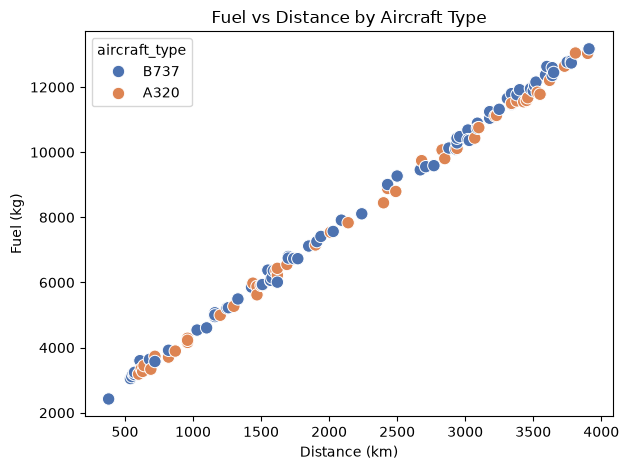

In [5]:
sns.scatterplot(data=df, x='distance_km', y='fuel_kg', hue='aircraft_type', s=80, palette='deep')
plt.title('Fuel vs Distance by Aircraft Type')
plt.xlabel('Distance (km)')
plt.ylabel('Fuel (kg)')
plt.tight_layout()
plt.show()

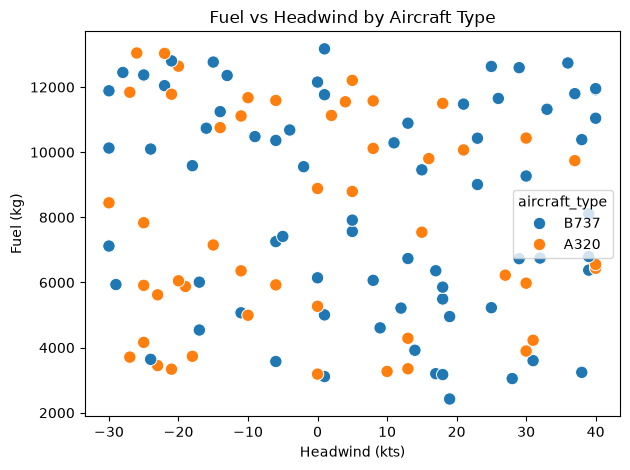

In [6]:
sns.scatterplot(data=df, x='headwind_kts', y='fuel_kg', hue='aircraft_type', s=80)
plt.title('Fuel vs Headwind by Aircraft Type')
plt.xlabel('Headwind (kts)')
plt.ylabel('Fuel (kg)')
plt.tight_layout()
plt.show()

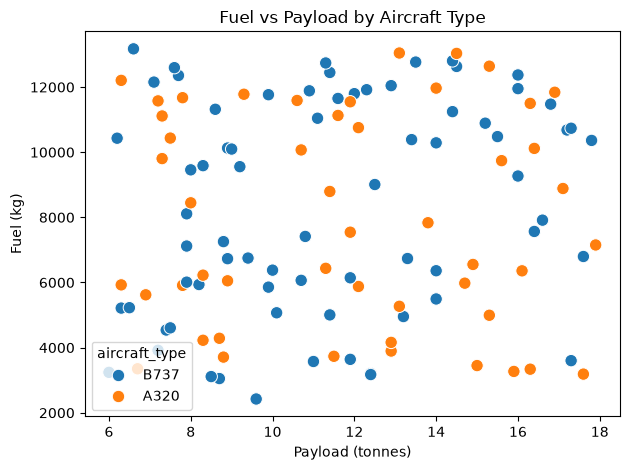

In [7]:
sns.scatterplot(data=df, x='payload_tonnes', y='fuel_kg', hue='aircraft_type', s=80)
plt.title('Fuel vs Payload by Aircraft Type')
plt.xlabel('Payload (tonnes)')
plt.ylabel('Fuel (kg)')
plt.tight_layout()
plt.show()

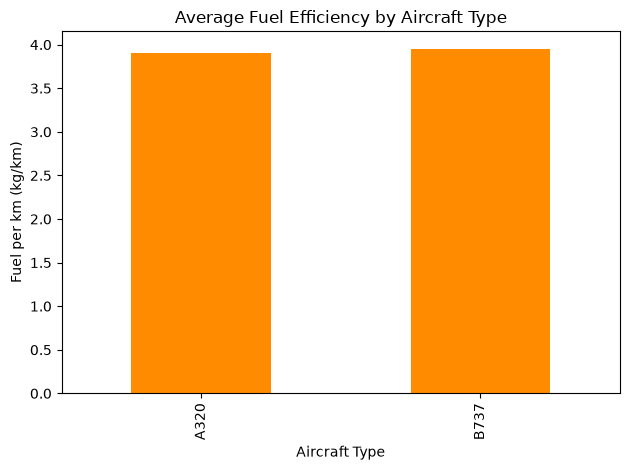

,fuel_per_km
aircraft_type,
A320,3.906
B737,3.955


In [8]:
df['fuel_per_km'] = df['fuel_kg'] / df['distance_km']
df.groupby('aircraft_type')['fuel_per_km'].mean().sort_values().plot(kind='bar', color='darkorange')
plt.title('Average Fuel Efficiency by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Fuel per km (kg/km)')
plt.tight_layout()
plt.show()
df[['aircraft_type', 'fuel_per_km']].groupby('aircraft_type').mean().round(3)

## Key takeaways

- Fuel usage increases strongly with flight distance.
- Aircraft type appears to influence fuel burn patterns.
- Headwind and payload also appear to affect consumption, though the effect varies by aircraft and route.
- The `fuel_per_km` metric helps compare efficiency across aircraft types more fairly.